In [103]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [104]:
df=pd.read_csv('polynomial_regression_data.csv')
df.head()

,x,y
0,-10.0000,-2498.1643
1,-9.8995,-2459.9145
2,-9.7990,-2351.9190
3,-9.6985,-2240.7428
4,-9.5980,-2262.4694


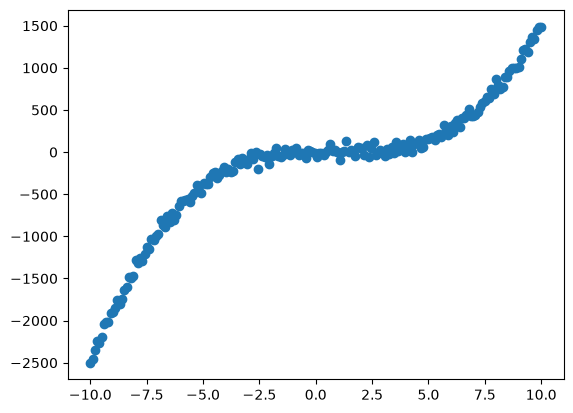

In [105]:
X=df[['x']]
Y=df['y']
plt.scatter(X,Y)

In [106]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y, test_size=0.25, random_state=42)

In [107]:
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()
regression_1.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[127.84]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['x']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-178.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [108]:
from sklearn.metrics import r2_score
score=r2_score(y_test, regression_1.predict(x_test))
print(score)

0.7846518502655067


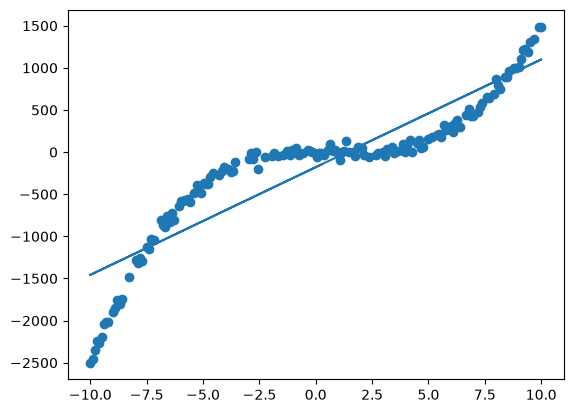

In [109]:
plt.plot(x_train, regression_1.predict(x_train))
plt.scatter(x_train, y_train)

In [110]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=5, include_bias=True)

x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)


In [111]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(x_train_poly, y_train)
y_pred=regression.predict(x_test_poly)
score=r2_score(y_test, y_pred)
print(score)

0.9956554672289453


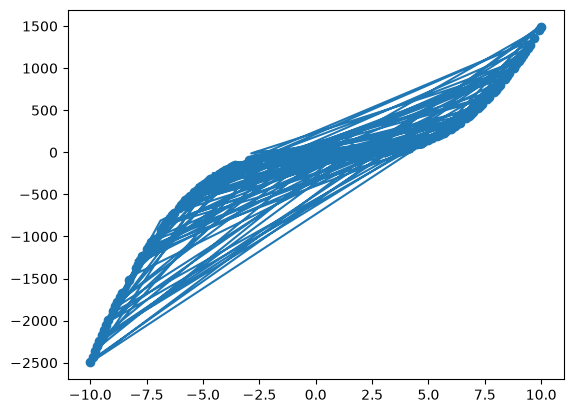

In [112]:
plt.scatter(x_train, regression.predict(x_train_poly))
plt.plot(x_train, y_train)


In [121]:
from sklearn.pipeline import Pipeline
def poly_regression(degree):
    x_new=pd.read_csv('polynomial_regression_test_data.csv')
    X_new = x_new[['x']] 
    poly_feature=PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg=LinearRegression()
    poly_reg=Pipeline([
        ("poly_feature", poly_feature),
        ("lin_reg", lin_reg)
    ])
    poly_reg.fit(x_train, y_train)
    y_pred_new = poly_reg.predict(X_new) 
    plt.plot(x_new, y_pred_new, 'r', label='degree')
    plt.scatter(x_train, y_train, color='green', label='Train data')
    plt.scatter(x_test, y_test, color='blue', label='Test data')
    plt.legend(loc="upper left")
    plt.show()



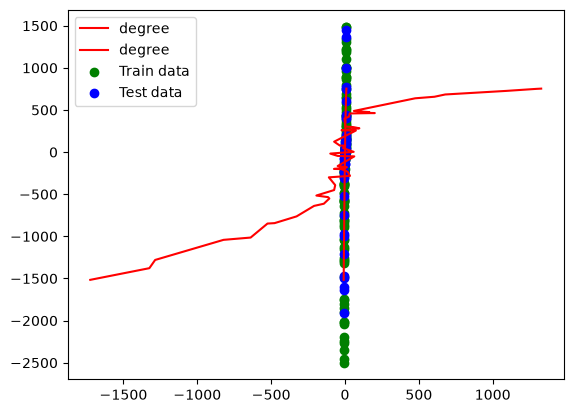

In [122]:
poly_regression(2)

In [ ]:
w